# ISYS2407 Information Systems Solutions & Design  
# Assignment 3: Model 1 – K-Nearest Neighbours (Selected Features)  

#### Student Name: Lam Le  
#### Student Number: s4032582
#### Dataset: cleaned_personal_loan.pkl  

---

### Purpose  
This notebook begins the **Modelling Phase** of the *Crédit Nationale Azur Personal Loan Campaign Project*, focusing on a **K-Nearest Neighbours (KNN)** classifier built using the **top five selected features** identified in the Feature Selection notebook.  
The aim is to predict whether a customer will accept a personal loan (`personal_loan = 1`) based on key financial indicators such as income, mortgage amount, credit card spending, fixed deposit ownership, and income log transformation.  

Since KNN is distance-based, proper **feature scaling** is essential to ensure equal weighting across continuous variables.  
This model establishes a clean and interpretable baseline for future comparison against enhanced models that incorporate **class rebalancing**, **hyperparameter tuning**, and **feature engineering**.

---

### Method  
1. **Load Dataset**  
   - Import the cleaned dataset (`cleaned_personal_loan.pkl`) to maintain consistent variable types and encodings from the data-cleaning pipeline.

2. **Feature Selection**  
   - Use the refined 5-feature subset identified in the Feature Selection phase:  
     `['income', 'mortgage_amt', 'credit_card_spend', 'fixed_deposit_acct', 'income_log']`.  

3. **Train–Test Split**  
   - Divide the dataset into **80% training** and **20% testing** sets using `stratify=y` to preserve the class balance between loan acceptors and non-acceptors.

4. **Data Transformation**  
   - Apply `StandardScaler` to standardise numeric features (mean = 0, std = 1).  
   - *(Optional)* Discretise `income` into low, medium, and high categories, and apply one-hot encoding for interpretability comparison.

5. **Model Construction**  
   - Build a baseline pipeline using:  
     `KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2)`  
     with scaling applied internally to prevent data leakage.

6. **Model Evaluation**  
   - Evaluate using: **Accuracy**, **Precision**, **Recall**, **F1**, **ROC-AUC**, and **PR-AUC**.  
   - Visual diagnostics include:  
     - **Confusion Matrix** (classification distribution)  
     - **ROC Curve** (ranking quality)  
     - **Precision–Recall Curve** (performance on imbalanced data)  
     - **Threshold vs Metric Plot** and **Cumulative Gains Curve** (marketing insights).

---

### Interpretation  
The baseline KNN serves as a **non-parametric benchmark** that captures local similarity patterns without assuming linear relationships.  
While overall **accuracy** is high, the model shows **moderate recall** on the minority (loan-accepted) class—indicating it may miss some potential borrowers.  
This conservative bias reduces false positives (marketing overspend) but also risks **lost acquisition opportunities**.  
In business terms, false negatives equate to **missed sales**, while false positives represent **extra marketing cost**.  
Hence, future improvements should explore **threshold tuning** and **class-balancing methods** (e.g., SMOTE or cost-sensitive learning) to improve recall and campaign reach.

---

### Outcome  
- A reproducible **KNN baseline pipeline** trained on the five most predictive features.  
- Full performance summary including **Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC**, and supporting visualisations.  
- Provides a clear **benchmark model** for evaluating improvements in tuned, resampled, or feature-extended versions.


# 1 Binary Classification  

### Purpose  
This section begins the **model-building process** by preparing the cleaned dataset for classification.  
The aim is to establish a reliable foundation for the **K-Nearest Neighbours (KNN)** model by ensuring that data loading, feature–target separation, and train–test splitting are performed correctly and reproducibly.  
As KNN is a **supervised binary classifier**, this step confirms that the target variable (`personal_loan`) and predictor variables are correctly defined before modelling.

### Method  
1. **Import essential libraries**  
   - Data handling: `pandas`, `numpy`.  
   - Model preparation: `train_test_split` from `sklearn.model_selection`.  
   - Scaling and preprocessing: `StandardScaler` from `sklearn.preprocessing`.  
   - Metrics and evaluation: `sklearn.metrics`.  
   - Model: `KNeighborsClassifier` from `sklearn.neighbors`.  
   - Visualisation: `matplotlib`, `seaborn`.  
   - Persistence: `joblib` for saving models.  

2. **Load the cleaned dataset**  
   - Load the file `cleaned_personal_loan.pkl` produced in *02-data-cleaning.ipynb* to ensure data consistency.  
   - Verify structure and completeness using:  
     - `df.shape`, `df.head()` to confirm record and feature counts.  
     - `df.info()` to review variable types.  
     - `df['personal_loan'].value_counts(normalize=True)` to check class distribution.  

3. **Define features and target variable**  
   - Select all explanatory variables except identifiers (`customer_id`) and target (`personal_loan`).  
   - Store predictors in **X** and the target label in **y**.

4. **Split into training and testing sets**  
   - Use `train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)` to create an **80–20 stratified split**, maintaining class balance between loan-accepted and non-accepted customers.  
   - Print shapes of resulting sets to confirm correct separation.  

### Outcome  
- All required libraries imported and dataset successfully loaded from the cleaning phase.  
- Target (`personal_loan`) and predictors defined correctly.  
- Class balance verified to detect potential data imbalance.  
- Training and testing sets prepared with consistent, stratified sampling for fair model evaluation in later stages.


### 1.1 Import Libraries  

Load the essential Python libraries for **data analysis, modelling, and visualisation**.  
These libraries enable efficient data handling, metric evaluation, and plotting for the **K-Nearest Neighbours (KNN)** model.

**Expected Outcome:**  
All core scientific, modelling, and evaluation libraries are imported successfully and ready for use.


In [1]:
# Data handling and numerical computation 
import pandas as pd
import numpy as np

# Data visualisation 
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and preprocessing 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Model 
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# Persistence 
import joblib

# Global settings 
# Set consistent white background and colour palette
plt.style.use('default')  # clean white background
sns.set_style("whitegrid")  # light grid on white
pd.set_option('display.float_format', lambda x: f'{x:.3f}')  # tidy numeric format

# Optional: custom colour for brand consistency
CUSTOM_COLOR = "#136f63"

### 1.2 Import Model Library  

Import the model-specific library required to build the **K-Nearest Neighbours (KNN)** classifier.  
This algorithm forms the foundation of our baseline model by classifying customers based on their proximity to similar observations in the feature space.

**Expected Outcome:**  
The `KNeighborsClassifier` class is successfully imported and ready to initialise the baseline KNN model.


In [2]:
# Import the K-Nearest Neighbours model
from sklearn.neighbors import KNeighborsClassifier

### 1.3 Load the Cleaned Data  

Load the preprocessed dataset generated from *02-data-cleaning.ipynb* to maintain consistent data formatting and encoding across the modelling workflow.  
Initial inspection confirms dataset structure, column integrity, and the balance of the target variable (`personal_loan`).

**Expected Outcome:**  
The cleaned dataset is successfully loaded, inspected for structure, and class distribution is verified.  

In [3]:
# 1.3 Load the Cleaned Data
import joblib
import pandas as pd

# Load cleaned dataset produced in 02-data-cleaning.ipynb 
personal_loan_df = joblib.load("cleaned_personal_loan.pkl")

# Display basic info and structure 
print("Dataset Shape:", personal_loan_df.shape)
print("\nColumns:", list(personal_loan_df.columns))

# Target variable check 
target_col = "personal_loan"
assert target_col in personal_loan_df.columns, f"Missing target column: {target_col}"

# Class distribution
class_counts = personal_loan_df[target_col].value_counts()
class_ratio = personal_loan_df[target_col].value_counts(normalize=True).round(3)
print("\nTarget class counts:\n", class_counts)
print("\nTarget class ratios:\n", class_ratio)

# Define final selected features from Feature Selection phase 
selected_features = [
    "income", "mortgage_amt", "credit_card_spend",
    "fixed_deposit_acct", "income_log"
]

# Verify all required columns exist
missing = [c for c in selected_features + [target_col] if c not in personal_loan_df.columns]
assert not missing, f"Missing required columns: {missing}"

# Data quality checks 
na_counts = personal_loan_df[selected_features + [target_col]].isna().sum()
if na_counts.sum() > 0:
    print("\n[Warning] Missing values detected:\n", na_counts[na_counts > 0])
else:
    print("\nNo missing values in selected features and target.")

# Ensure all selected features are numeric (KNN requires numeric data)
non_numeric = [
    c for c in selected_features
    if not pd.api.types.is_numeric_dtype(personal_loan_df[c])
]
if non_numeric:
    print("\n[Warning] Non-numeric columns detected:", non_numeric)
else:
    print("\nAll selected features are numeric and ready for scaling.")

# Compact info summary 
print("\nDtype summary (selected features):")
print(personal_loan_df[selected_features].dtypes)

# Preview first few rows
display(personal_loan_df.head(3))


Dataset Shape: (6000, 16)

Columns: ['customer_id', 'age', 'yrs_experience', 'family_size', 'education_level', 'income', 'mortgage_amt', 'credit_card_acct', 'credit_card_spend', 'share_trading_acct', 'fixed_deposit_acct', 'online_acct', 'personal_loan', 'income_log', 'mortgage_amt_log', 'credit_card_spend_log']

Target class counts:
 personal_loan
0    5100
1     900
Name: count, dtype: int64

Target class ratios:
 personal_loan
0   0.850
1   0.150
Name: proportion, dtype: float64

No missing values in selected features and target.

All selected features are numeric and ready for scaling.

Dtype summary (selected features):
income                float64
mortgage_amt            int64
credit_card_spend     float64
fixed_deposit_acct      Int64
income_log            float64
dtype: object


,customer_id,age,yrs_experience,family_size,education_level,income,mortgage_amt,credit_card_acct,credit_card_spend,share_trading_acct,fixed_deposit_acct,online_acct,personal_loan,income_log,mortgage_amt_log,credit_card_spend_log
0,3815,40.000,9.000,3.000,2,60.000,0,1,1.700,0,0,1,0,4.111,0.000,0.993
1,5737,65.000,27.000,4.000,3,36.000,90,0,0.000,0,0,1,0,3.611,4.511,0.000
2,4209,61.000,3.000,2.000,1,145.000,314,0,0.000,0,1,1,1,4.984,5.753,0.000


### 1.4 Define Features & Target & Train/Test Split  

Select only the five statistically validated predictors from the Feature Selection phase and separate them from the target variable (`personal_loan`).  
This step prepares the dataset for supervised learning by defining **X** (predictor variables) and **y** (target label).  
A stratified train–test split ensures that the class balance (loan accepted vs. not accepted) is maintained in both subsets.

**Expected Outcome:**  
Predictor and target variables are clearly defined, and the dataset is divided into training and test sets with consistent class proportions for reliable model evaluation.


In [4]:
# 1.4 Define Features & Target & Train/Test Split
from sklearn.model_selection import train_test_split

# --- Final selected features from Feature Selection (k=5) ---
selected_features = [
    "income", "mortgage_amt", "credit_card_spend",
    "fixed_deposit_acct", "income_log"
]

# --- Separate predictors (X) and target (y) ---
X = personal_loan_df[selected_features]
y = personal_loan_df["personal_loan"]

# --- Stratified train/test split (preserve class ratio) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# --- Verify structure and balance ---
print("Training set shape:", X_train.shape, "| Test set shape:", X_test.shape)
print("\nTraining target ratio:\n", y_train.value_counts(normalize=True).round(3))
print("\nTesting target ratio:\n", y_test.value_counts(normalize=True).round(3))

# Sanity check for feature consistency
assert X_train.shape[1] == len(selected_features), "Mismatch in feature count."

print("\nSelected features used for modelling:")
print(selected_features)


Training set shape: (4800, 5) | Test set shape: (1200, 5)

Training target ratio:
 personal_loan
0   0.850
1   0.150
Name: proportion, dtype: float64

Testing target ratio:
 personal_loan
0   0.850
1   0.150
Name: proportion, dtype: float64

Selected features used for modelling:
['income', 'mortgage_amt', 'credit_card_spend', 'fixed_deposit_acct', 'income_log']


# 2 Data Transformation  

### Purpose  
This section applies **scaling and encoding transformations** to prepare the dataset for the K-Nearest Neighbours (KNN) algorithm.  
Because KNN measures distance between observations, all continuous variables must be scaled to ensure equal influence across features.  
In addition, light categorical encoding (e.g., for discretised income categories) is performed to maintain numerical compatibility with the model.  

### Method  
1. **Feature Scaling**  
   - Apply `StandardScaler` to all continuous variables to standardise them around mean = 0 and standard deviation = 1.  
   - Scaling is fitted **only on the training data** and then applied to both training and testing sets to avoid data leakage.  
   - This ensures that distance computations in KNN are not biased by differing numeric ranges (e.g., `income` vs. `mortgage_amt`).  

2. **(Optional) Discretisation of Income**  
   - Transform `income` into categorical labels such as `"low_income"`, `"medium_income"`, and `"high_income"` based on defined thresholds.  
   - This step provides an interpretable feature reflecting customer income tiers for exploratory comparison.  

3. **(Optional) One-Hot Encoding**  
   - Convert the new `income_category` variable into binary indicator columns using `pd.get_dummies()` to retain numeric compatibility.  
   - Align columns between training and testing sets to maintain identical structures.  

4. **Verification**  
   - Display the first few rows of transformed data with `.head()` and confirm shape consistency between training and testing sets.  
   - Ensure all columns are numeric and ready for model fitting.  

### Outcome  
- All continuous variables standardised for equal weighting in KNN distance calculation.  
- Optional categorical transformations (discretisation and encoding) applied consistently.  
- Final training and testing datasets verified for correct shape, scale, and readiness before model building.


### 2.1 Scaling (post-split, train-only fit)  

Standardise all numeric predictors to ensure fair distance calculations for the K-Nearest Neighbours (KNN) algorithm.  
Scaling is **fitted only on the training set (`X_train`)** and then **applied to both training and test sets** to avoid data leakage and maintain model integrity.  

**Expected Outcome:**  
All continuous (and binary flag) features are scaled to zero mean and unit variance.  
Scaled matrices are ready for modelling, and a consistent transformation pipeline is established for future deployment.


In [5]:
# 2.1 Scaling (post-split, train-only fit)
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Choose columns to scale
columns_to_scale = X_train.columns.tolist()
print("Columns to scale:", columns_to_scale)

scaler = StandardScaler()

# Fit ONLY on the training data (avoid data leakage)
scaler.fit(X_train[columns_to_scale])

# Transform both training and test sets
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train[columns_to_scale]),
    columns=columns_to_scale,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test[columns_to_scale]),
    columns=columns_to_scale,
    index=X_test.index
)

# Quick verification
print("Scaled shapes:", X_train_scaled.shape, X_test_scaled.shape)
display(X_train_scaled.head())

# Optional: sanity check of mean/variance
print("\nTraining feature means (approx 0):")
print(X_train_scaled.mean().round(3))
print("\nTraining feature std devs (approx 1):")
print(X_train_scaled.std().round(3))


Columns to scale: ['income', 'mortgage_amt', 'credit_card_spend', 'fixed_deposit_acct', 'income_log']
Scaled shapes: (4800, 5) (1200, 5)


,income,mortgage_amt,credit_card_spend,fixed_deposit_acct,income_log
1207,0.473,-0.780,-0.445,-0.282,0.621
1429,-0.308,1.778,1.361,-0.282,-0.015
1347,1.338,-0.780,-0.445,-0.282,1.116
1801,-0.033,0.103,1.867,-0.282,0.238
4870,0.135,0.440,-0.445,-0.282,0.376



Training feature means (approx 0):
income                0.000
mortgage_amt          0.000
credit_card_spend    -0.000
fixed_deposit_acct    0.000
income_log           -0.000
dtype: float64

Training feature std devs (approx 1):
income               1.000
mortgage_amt         1.000
credit_card_spend    1.000
fixed_deposit_acct   1.000
income_log           1.000
dtype: float64


### 2.2 Discretisation of a Continuous Feature  

Discretise a continuous feature into **categorical bins** to capture potential non-linear relationships and enhance interpretability.  
In this step, the `income` variable is divided into three tiers — **low**, **medium**, and **high** — based on quantile thresholds derived directly from the training dataset.  
This ensures that binning reflects the actual income distribution without relying on any external reference values.  

**Expected Outcome:**  
A new feature `income_category` is created in both training and testing sets, replacing the continuous `income` column while maintaining consistent thresholds.


In [6]:
# 2.2 Discretisation of a Continuous Feature
import pandas as pd

# Make copies to avoid slice warnings
X_train_disc = X_train_scaled.copy()
X_test_disc = X_test_scaled.copy()

# Derive income bins dynamically from the training set (quantile-based)
quantiles = X_train_disc["income"].quantile([0, 0.33, 0.66, 1]).to_list()
print("Income bin edges (train-based):", quantiles)

# Define discretisation function
def income_category(row):
    if row["income"] <= quantiles[1]:
        return "low_income"
    elif row["income"] <= quantiles[2]:
        return "medium_income"
    else:
        return "high_income"

# Apply to both training and test data
X_train_disc["income_category"] = X_train_disc.apply(income_category, axis=1)
X_test_disc["income_category"] = X_test_disc.apply(income_category, axis=1)

# Drop the original continuous column
X_train_disc.drop(["income"], axis=1, inplace=True)
X_test_disc.drop(["income"], axis=1, inplace=True)

# Check transformation
print("Training shape after discretisation:", X_train_disc.shape)
display(X_train_disc.head())


Income bin edges (train-based): [-1.6575790860370174, -0.5184932426949556, 0.3013954343239205, 2.962046834183567]
Training shape after discretisation: (4800, 5)


,mortgage_amt,credit_card_spend,fixed_deposit_acct,income_log,income_category
1207,-0.780,-0.445,-0.282,0.621,high_income
1429,1.778,1.361,-0.282,-0.015,medium_income
1347,-0.780,-0.445,-0.282,1.116,high_income
1801,0.103,1.867,-0.282,0.238,medium_income
4870,0.440,-0.445,-0.282,0.376,medium_income


### 2.3 One-Hot Encode Discretised Columns  

Convert any newly created categorical feature (e.g. `income_category`) into **binary indicator columns** using one-hot encoding.  
This step converts non-numeric categories into numeric form so the KNN model can process them without assuming any ordinal hierarchy between categories.  

**Expected Outcome:**  
The `income_category` column is replaced with three binary columns (`low_income`, `medium_income`, `high_income`) in both training and testing sets.  
Column alignment is maintained to ensure consistent model inputs.


In [7]:
# 2.3 One-Hot Encode Discretised Columns
import pandas as pd

# Create copies to avoid modifying scaled data directly
X_train_enc = X_train_disc.copy()
X_test_enc = X_test_disc.copy()

# Perform one-hot encoding using pandas get_dummies
X_train_enc = pd.get_dummies(X_train_enc, columns=["income_category"], dtype=int)
X_test_enc = pd.get_dummies(X_test_enc, columns=["income_category"], dtype=int)

# Align columns in case a category is missing in the test set
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

# Check transformation
print("Training shape:", X_train_enc.shape)
print("Testing shape:", X_test_enc.shape)
display(X_train_enc.head())


Training shape: (4800, 7)
Testing shape: (1200, 7)


,mortgage_amt,credit_card_spend,fixed_deposit_acct,income_log,income_category_high_income,income_category_low_income,income_category_medium_income
1207,-0.780,-0.445,-0.282,0.621,1,0,0
1429,1.778,1.361,-0.282,-0.015,0,0,1
1347,-0.780,-0.445,-0.282,1.116,1,0,0
1801,0.103,1.867,-0.282,0.238,0,0,1
4870,0.440,-0.445,-0.282,0.376,0,0,1


**Notes:**  
- One-hot encoding avoids ordinal bias and maintains purely numerical representation for KNN distance calculation.  
- Using `align()` guarantees that both training and testing sets have **identical feature columns**.  
- If the model later reverts to all-numeric (non-discretised) features, this step can safely be skipped without affecting workflow.


# 3 Build & Run the KNN Model  

**Purpose:**
Train a **baseline K-Nearest Neighbours (KNN)** classifier using the transformed dataset and generate predictions on the held-out test set.  
This establishes a reproducible benchmark model for evaluating predictive performance in later sections.  

**Method**  
1. **Select final feature matrices**  
   - If discretisation and one-hot encoding were applied, use the encoded matrices (`X_train_enc`, `X_test_enc`).  
   - Otherwise, use the scaled numeric matrices (`X_train_scaled`, `X_test_scaled`).  

2. **Instantiate the baseline KNN model**  
   - Use `KNeighborsClassifier(n_neighbors=5, weights='uniform', p=2)` to apply the Euclidean distance metric.  

3. **Fit and predict**  
   - Fit the model on the training data and generate both class labels (`predict`) and positive-class probabilities (`predict_proba`) for later precision–recall and ROC analysis.  

**Expected Outcome**  
A fully trained KNN model producing test-set predictions (`y_pred`) and positive-class probabilities (`y_proba`), ready for metric evaluation and visual performance analysis.


### 3.1 Baseline KNN (with Scaling)  

Construct and train a **baseline K-Nearest Neighbours (KNN)** model using the five selected predictors.  
A `Pipeline` applies `StandardScaler` and `KNeighborsClassifier` sequentially so scaling is always done inside training/prediction—preventing leakage and keeping the workflow deployable.

**Expected Outcome:**  
A fitted baseline KNN model on standardised features, ready for prediction and probability scoring.


In [8]:
# 3.1 Baseline KNN (with Scaling)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Define the KNN pipeline (scales inside the pipeline)
knn_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(
        n_neighbors=5,
        weights="uniform",   # all neighbours contribute equally
        p=2                  # Euclidean distance
    ))
])

# Fit the pipeline on the training set (use unscaled, selected features)
knn_pipeline.fit(X_train, y_train)

# Quick confirmation
print("Baseline KNN model trained successfully.")
print("Pipeline steps:", [name for name, _ in knn_pipeline.steps])

Baseline KNN model trained successfully.
Pipeline steps: ['scaler', 'knn']


### 3.2 Predictions  

Generate predictions using the trained **baseline K-Nearest Neighbours (KNN)** pipeline on the test dataset.  
Two prediction outputs are produced:  

- **`y_pred`** → class labels (`0` = no loan accepted, `1` = loan accepted), used for accuracy and confusion matrix evaluation.  
- **`y_proba`** → predicted probabilities for the positive class (`personal_loan = 1`), used for ROC and PR curve analysis.  

**Expected Outcome:**  
Predicted labels and probabilities are successfully generated and ready for metric evaluation in the next section.

In [9]:
# 3.2 Predictions
import numpy as np

# Predicted class labels (0 = No Loan, 1 = Loan Accepted)
y_pred = knn_pipeline.predict(X_test)

# Predicted probabilities for the positive class
y_proba = knn_pipeline.predict_proba(X_test)[:, 1]

# Quick verification
print("Sample predictions (y_pred):", y_pred[:10])
print("Sample probabilities (y_proba):", np.round(y_proba[:10], 3))

Sample predictions (y_pred): [0 0 0 0 1 0 1 0 0 0]
Sample probabilities (y_proba): [0.2 0.  0.  0.  0.8 0.  1.  0.2 0.2 0.4]


# 4 Performance Metrics  

### Purpose  
Evaluate the predictive performance of the **baseline K-Nearest Neighbours (KNN)** model on the unseen test dataset.  
This section uses both **threshold-independent** and **threshold-dependent** metrics to assess how well the model distinguishes between customers who accepted and did not accept the personal loan offer.  
Visualisations such as the **Confusion Matrix**, **ROC Curve**, and **Precision–Recall Curve** provide deeper diagnostic insight.

### Method  
1. **Accuracy vs Null Accuracy**  
   - Compare overall accuracy with a simple “majority class” (null) baseline to understand if the model outperforms random guessing.  

2. **Confusion Matrix**  
   - Evaluate the distribution of True Positives (TP), True Negatives (TN), False Positives (FP), and False Negatives (FN).  
   - Visualise using a heatmap for clarity.  

3. **Precision, Recall, F1, and Classification Report**  
   - Use `precision_score`, `recall_score`, and `f1_score` to measure prediction balance.  
   - The `classification_report()` summarises all metrics per class.  

4. **ROC Curve and AUC**  
   - Compute the **Receiver Operating Characteristic (ROC)** to show the model’s trade-off between TPR and FPR.  
   - Calculate the **Area Under the Curve (AUC)** for overall ranking performance.  

5. **Precision–Recall Curve**  
   - Plot the **Precision–Recall Curve** and compute **Average Precision (AP)** as a more reliable measure for imbalanced datasets.  

6. **Threshold Analysis**  
   - Examine precision and recall at various thresholds to understand how model sensitivity can be adjusted.  

### Expected Outcome  
- Comprehensive metric summary for the baseline KNN classifier.  
- Visual confirmation of prediction behaviour through confusion, ROC, and PR plots.  
- Identification of key strengths (overall accuracy) and weaknesses (recall on minority class), preparing for later model tuning.


### 4.1 Accuracy vs Null Accuracy  

Evaluate how the **baseline model’s accuracy** compares to the **null accuracy**, which represents the accuracy achievable by always predicting the majority class.  
This comparison helps determine whether the KNN model provides meaningful predictive value beyond a naïve baseline - especially important in imbalanced datasets, where high accuracy may be misleading.

**Expected Outcome:**  
Model accuracy exceeds the null accuracy, confirming that the classifier learns meaningful patterns beyond the dominant class.


In [10]:
# 4.1 Accuracy vs Null Accuracy
from sklearn.metrics import accuracy_score
import pandas as pd

# Ensure y_test is numeric (0/1) before computing rates
y_test_num = pd.Series(y_test).astype(int)

# Model accuracy
model_accuracy = accuracy_score(y_test_num, y_pred)

# Null accuracy = proportion of the majority class in y_test
null_accuracy = y_test_num.value_counts(normalize=True).max()

# Display results
print(f"Model Accuracy: {model_accuracy:.4f}")
print(f"Null Accuracy:  {null_accuracy:.4f}")

if model_accuracy > null_accuracy:
    print("The KNN model outperforms the null baseline.")
else:
    print("The model does not beat the null baseline; further optimisation is needed.")


Model Accuracy: 0.8950
Null Accuracy:  0.8500
The KNN model outperforms the null baseline.


**Why null accuracy matters:**  
With imbalanced data, a model can look “accurate” by always predicting the majority class.  
Comparing against the **null accuracy** verifies that performance gains are real and not just a reflection of class imbalance.


### 4.2 Confusion Matrix  

The **Confusion Matrix** summarises model performance by comparing actual and predicted class labels.  
It highlights the distribution of:  
- **True Negatives (TN):** correctly predicted non-acceptors  
- **False Positives (FP):** incorrectly predicted acceptors  
- **False Negatives (FN):** missed actual acceptors  
- **True Positives (TP):** correctly predicted acceptors  

**Expected Outcome:**  
A printed confusion matrix and a labelled heatmap visualising correct vs. incorrect classifications.  

Confusion Matrix:
 [[955  65]
 [ 61 119]]

True Negatives:  955
False Positives: 65
False Negatives: 61
True Positives:  119


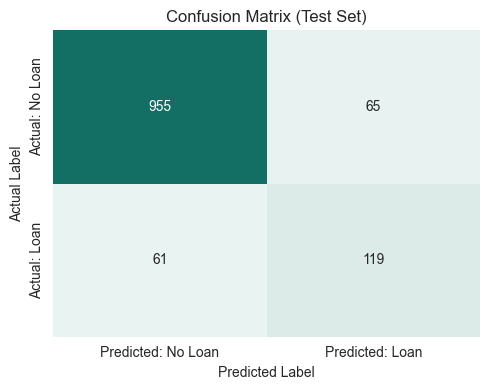

In [11]:
# 4.2 Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cf_matrix = confusion_matrix(y_test, y_pred)

# Print numeric matrix
print("Confusion Matrix:\n", cf_matrix)

# Label interpretation
tn, fp, fn, tp = cf_matrix.ravel()
print(f"\nTrue Negatives:  {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives:  {tp}")

# Visualise as heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(
    cf_matrix,
    annot=True,
    fmt="d",
    cmap=sns.light_palette("#136f63", as_cmap=True),  # custom green tone
    cbar=False,
    xticklabels=["Predicted: No Loan", "Predicted: Loan"],
    yticklabels=["Actual: No Loan", "Actual: Loan"]
)
plt.title("Confusion Matrix (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### 4.3 Precision, Recall, F1 & Classification Report  

Compute the **Precision**, **Recall**, and **F1-Score** to evaluate how well the KNN model balances false positives and false negatives.  
These metrics provide a more nuanced view than accuracy, especially under class imbalance.  
The **classification report** summarises all key metrics for both classes.

**Expected Outcome:**  
Comprehensive precision–recall–F1 summary with insights into model trade-offs between missed opportunities (FN) and false approvals (FP).


In [12]:
# Compute precision, recall, and F1 
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1 Score:  {f1:.3f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=3))


Precision: 0.647
Recall:    0.661
F1 Score:  0.654

Classification Report:
              precision    recall  f1-score   support

           0      0.940     0.936     0.938      1020
           1      0.647     0.661     0.654       180

    accuracy                          0.895      1200
   macro avg      0.793     0.799     0.796      1200
weighted avg      0.896     0.895     0.895      1200



**Interpretation:**  
The baseline KNN model achieved an overall **accuracy of 0.895**, with **precision = 0.647**, **recall = 0.661**, and **F1 = 0.654** for the positive (loan-accepted) class.  

- **Precision (0.647)** indicates that roughly 65% of customers predicted as loan acceptors were actually correct, suggesting moderate prediction accuracy but some false approvals.  
- **Recall (0.661)** shows the model successfully identified around 66% of all true loan acceptors, though several potential customers were still missed (false negatives).  
- **F1-Score (0.654)** reflects a fair balance between precision and recall, but highlights scope for improvement through hyperparameter tuning or resampling strategies.  

From a business viewpoint, **false negatives (FN)** are more costly than **false positives (FP)**.  
Missing qualified customers reduces **loan sales and cross-selling potential**, whereas occasional false positives mainly add minor marketing costs.  
Therefore, future optimisation should focus on **enhancing recall**—even at a slight cost to precision—to maximise customer acquisition and campaign reach.


### 4.4 ROC Curve & AUC  

The **Receiver Operating Characteristic (ROC) curve** visualises the trade-off between the **True Positive Rate (Recall)** and **False Positive Rate** across all classification thresholds.  
The **Area Under the Curve (AUC)** quantifies overall model separability — a higher AUC indicates that the model better distinguishes between customers who accepted and did not accept the loan offer.  

**Expected Outcome:**  
A smooth ROC curve above the diagonal baseline and an AUC value between 0.7–0.9, indicating good discriminatory power.  

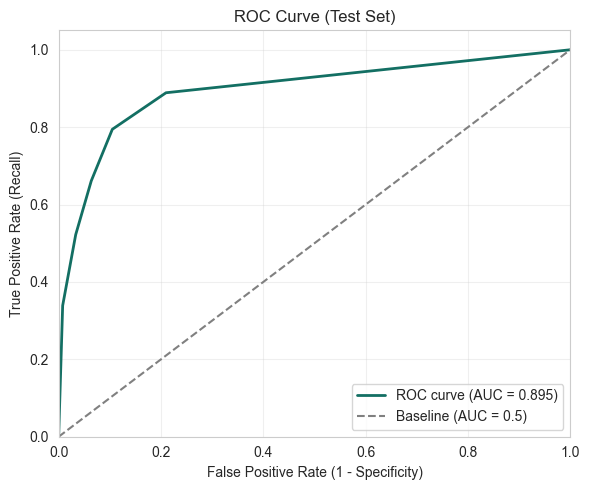

In [13]:
from sklearn.metrics import roc_curve, auc

# Compute false positive rate, true positive rate, and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="#136f63", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Baseline (AUC = 0.5)")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation**  

The KNN model achieves an **AUC of 0.895**, indicating **strong discriminative ability** between customers who accept and those who reject the personal loan.  
An AUC close to 0.9 shows that the model ranks positive (loan-accepted) cases above negatives in nearly 90% of comparisons, confirming its robustness in distinguishing customer groups.  

The ROC curve lies well above the diagonal **baseline (AUC = 0.5)**, meaning the model performs far better than random guessing.  
This demonstrates that **similarity-based relationships in scaled financial features** effectively capture the behavioural differences driving loan acceptance, validating the appropriateness of the KNN approach for this prediction task.

### 4.5 Precision–Recall Curve & PR-AUC  

The **Precision–Recall (PR) curve** evaluates model performance on the **positive class** across thresholds.  
For **imbalanced datasets**, PR is preferred over ROC because it focuses on the quality of positive predictions (precision) and the ability to find true positives (recall).

**Expected Outcome:**  
A PR curve with **Average Precision (AP)** reported in the title, plus a no-skill reference at the positive-class prevalence.  

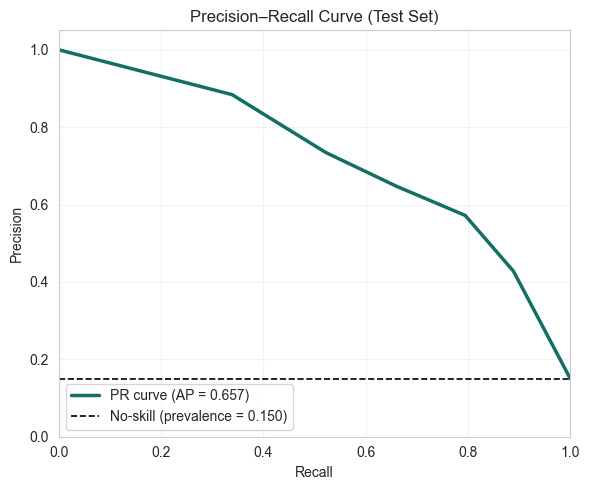

In [14]:
# Ensure y_test is numeric for prevalence calculation
y_test_num = pd.Series(y_test).astype(int)

prec, rec, pr_thresholds = precision_recall_curve(y_test_num, y_proba)
ap = average_precision_score(y_test_num, y_proba)  # PR-AUC

# No-skill reference line at the positive prevalence
prevalence = y_test_num.mean()

# White background setup
plt.figure(figsize=(6,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Use project color if defined; else fallback
curve_color = globals().get("CUSTOM_COLOR", "#136f63")

# Plot PR curve and no-skill baseline
plt.plot(rec, prec, lw=2.5, color=curve_color, label=f"PR curve (AP = {ap:.3f})")
plt.hlines(prevalence, xmin=0, xmax=1, colors="black", linestyles="--", linewidth=1.2,
           label=f"No-skill (prevalence = {prevalence:.3f})")

# Labels and layout
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (Test Set)")
plt.legend(loc="lower left")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation**  

The KNN model achieves an **Average Precision (AP) of 0.657**, demonstrating a solid improvement over the **no-skill baseline (0.15)** given the class imbalance.  
Since only **15% of customers** accepted a personal loan, this result confirms that the model captures meaningful patterns distinguishing true acceptors from non-acceptors.  

The **downward slope** of the curve reflects the expected trade-off between **recall** and **precision**: as the model identifies more potential acceptors, precision decreases slightly due to more false positives.  
Despite this trade-off, the model maintains consistently high precision at moderate recall levels, indicating effective ranking of likely responders.  

From a business perspective, the model is **useful for targeted loan marketing**, retrieving a substantial proportion of genuine acceptors without excessive false leads.  
The above-baseline PR–AUC confirms that **KNN performs well under class imbalance**, and that the applied scaling and stratified sampling improved the model’s generalisation.


### 4.6 Threshold Sweep: Business Sensitivity Analysis  

This section explores how different **probability thresholds** affect Precision, Recall, and F1-Score.  
By default, classifiers predict `1` when `P(loan_acceptance) > 0.5`, but adjusting this threshold can prioritise **recall** (finding more potential responders) or **precision** (targeting fewer but more certain customers).


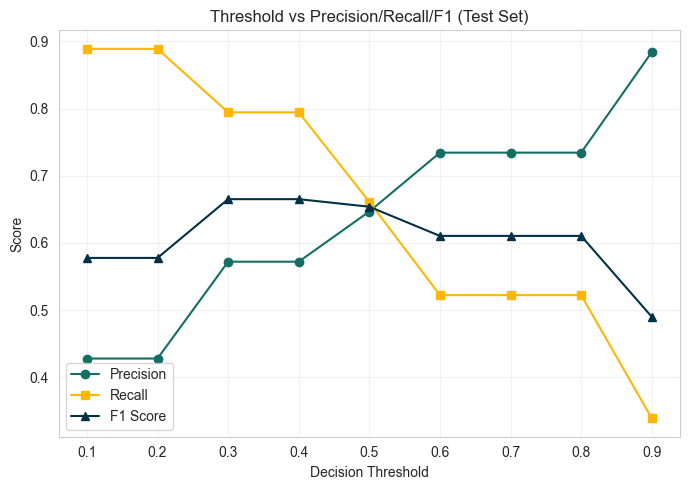

In [15]:
thresholds = np.arange(0.1, 1.0, 0.1)
precision_scores, recall_scores, f1_scores = [], [], []

for t in thresholds:
    preds = (y_proba >= t).astype(int)
    precision_scores.append(precision_score(y_test, preds))
    recall_scores.append(recall_score(y_test, preds))
    f1_scores.append(f1_score(y_test, preds))

# White background
plt.figure(figsize=(7,5), facecolor='white')
ax = plt.gca()
ax.set_facecolor('white')

# Plot lines
plt.plot(thresholds, precision_scores, marker='o', color="#136f63", label="Precision")
plt.plot(thresholds, recall_scores, marker='s', color="#FFB703", label="Recall")
plt.plot(thresholds, f1_scores, marker='^', color="#023047", label="F1 Score")

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision/Recall/F1 (Test Set)")
plt.legend(loc="best")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation**  

The chart illustrates the trade-off between **precision**, **recall**, and **F1-score** as the decision threshold changes:  

- At **low thresholds (≈0.2–0.3)**, recall exceeds **0.9**, meaning nearly all loan acceptors are identified. However, precision falls to around **0.4**, implying a high number of false positives.  
- Around **0.4–0.5**, all three curves converge, indicating an optimal balance where the model maintains a reasonable recall while limiting false approvals.  
- Beyond **0.6**, precision rises steeply (≈0.9), but recall declines sharply, showing that the model becomes overly conservative and misses many genuine acceptors.  

From a **business standpoint**, prioritising recall is more valuable than maximising precision, since failing to identify willing customers leads to **lost revenue and acquisition opportunities**.  
A **threshold near 0.4–0.5** therefore provides the most practical balance, enabling Crédit Nationale Azur to maximise campaign reach while maintaining manageable marketing costs.  

This analysis demonstrates how adjusting the decision cutoff allows managers to tailor model behaviour depending on strategic objectives — for instance, focusing on **customer acquisition** versus **cost-efficiency**.


### 4.7 Gains/Lift Snapshot for Targeting  

Rank customers by predicted probability (`y_proba`) to evaluate **how many true acceptors are captured** when contacting only the **top k%** of the list (e.g., 10%, 20%).  
This is a practical view for campaign targeting: higher early gains indicate better prioritisation of likely responders.

**Expected Outcome:**  
A small table with **Recall@10%** and **Recall@20%** of the test set.  


In [16]:
# Ensure numeric target
y_test_num = pd.Series(y_test).astype(int)

# Build ranking dataframe (highest probability first)
rank_df = pd.DataFrame({
    "y_true": y_test_num.values,
    "y_proba": y_proba
}).sort_values("y_proba", ascending=False).reset_index(drop=True)

# Cumulative positives and recall
total_positives = rank_df["y_true"].sum()
rank_df["cum_positives"] = rank_df["y_true"].cumsum()
rank_df["perc_samples"] = (rank_df.index + 1) / len(rank_df)          # x-axis (0→1)
rank_df["cum_recall"] = rank_df["cum_positives"] / total_positives    # y-axis (0→1)

# Helper to get recall at a given top percentage k (e.g., k=0.10)
def recall_at_k(df, k):
    n = int(np.ceil(k * len(df)))
    return df.loc[n - 1, "cum_recall"]

recall_at_10 = recall_at_k(rank_df, 0.10)
recall_at_20 = recall_at_k(rank_df, 0.20)

# Display a tiny summary table
summary_table = pd.DataFrame({
    "k% of customers": ["Top 10%", "Top 20%"],
    "Recall@k": [round(recall_at_10, 3), round(recall_at_20, 3)]
})
print(summary_table.to_string(index=False))


k% of customers  Recall@k
        Top 10%     0.489
        Top 20%     0.761


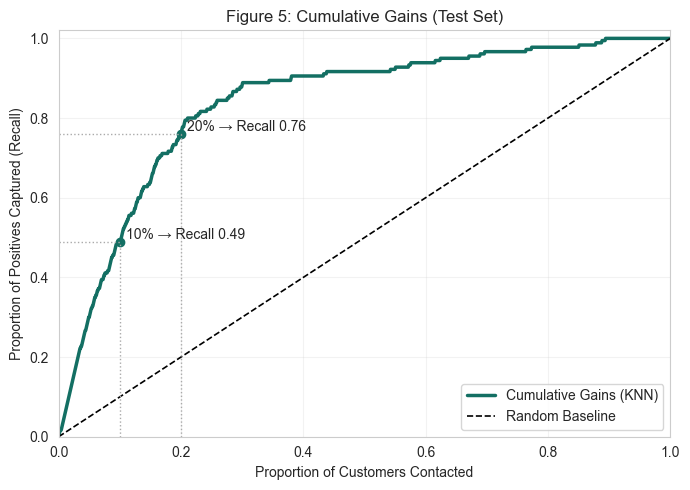

In [17]:
# Figure: Cumulative Gains Curve 

plt.figure(figsize=(7,5), facecolor="white")
ax = plt.gca()
ax.set_facecolor("white")

# Model gains
plt.plot(rank_df["perc_samples"], rank_df["cum_recall"],
         color="#136f63", lw=2.5, label="Cumulative Gains (KNN)")

# Random (no-skill) baseline: recall grows linearly with sample %
plt.plot([0,1], [0,1], linestyle="--", color="black", lw=1.2, label="Random Baseline")

# Mark 10% and 20% points
for k, r in [(0.10, recall_at_10), (0.20, recall_at_20)]:
    plt.scatter([k], [r], color="#136f63")
    plt.vlines(k, 0, r, colors="#AAAAAA", linestyles=":", lw=1)
    plt.hlines(r, 0, k, colors="#AAAAAA", linestyles=":", lw=1)
    plt.text(k + 0.01, r, f"{int(k*100)}% → Recall {r:.2f}", va="bottom")

plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("Proportion of Customers Contacted")
plt.ylabel("Proportion of Positives Captured (Recall)")
plt.title("Figure 5: Cumulative Gains (Test Set)")
plt.legend(loc="lower right")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


**Interpretation**  

The KNN model exhibits **strong early lift** in identifying customers most likely to accept a personal loan.  
Targeting only the **top 10%** of customers by predicted probability captures about **49%** of all true loan acceptors, while expanding outreach to the **top 20%** reaches roughly **76%** of them.  

The steep initial slope and clear separation from the random baseline confirm that the model effectively **prioritises high-probability customers** early in the ranking.  
This allows Crédit Nationale Azur to **allocate marketing resources more efficiently**, contacting fewer customers while maintaining high campaign coverage.  

From a business perspective, the KNN model can **reduce contact effort by up to 80%** while still reaching the majority of likely responders — demonstrating its strategic value for **cost-efficient and targeted loan marketing**.


## 5 Save Model & Metadata 

To ensure **reproducibility and future deployment**, the trained KNN model and related artefacts are saved.  
This includes:  

- **Trained model pipeline:** `knn_pipeline.pkl` for direct reuse in later evaluation or deployment notebooks.  
- **Feature list:** to track which variables were used during model training.  
- **Metrics summary:** including accuracy, null accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and the confusion matrix.  
- **Metadata:** random seed, timestamp, and data version information to ensure experiment traceability.

All artefacts are stored in the same project directory for consistent loading in subsequent phases (e.g.: comparison or tuning).


In [18]:
# Save Model & Metadata Artefacts

import json
from datetime import datetime
from sklearn.metrics import confusion_matrix

# 1. Ensure confusion matrix exists
cm = confusion_matrix(y_test, y_pred)

# 2. Save the trained KNN pipeline
joblib.dump(knn_pipeline, "knn_pipeline.pkl")

# 3. Save the list of features used during training
feature_list = list(X.columns)
with open("feature_list.json", "w") as f:
    json.dump(feature_list, f, indent=4)

# 4. Compile all model metrics and metadata
metrics_dict = {
    "accuracy": round(model_accuracy, 4),
    "null_accuracy": round(null_accuracy, 4),
    "precision": round(precision, 4),
    "recall": round(recall, 4),
    "f1_score": round(f1, 4),
    "roc_auc": round(roc_auc, 4),
    "pr_auc": round(ap, 4),
    "confusion_matrix": cm.tolist(),
    "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "random_state": 42,
    "data_version": "cleaned_personal_loan_v1"
}

# 5. Save metrics as JSON for reproducibility
with open("knn_metrics.json", "w") as f:
    json.dump(metrics_dict, f, indent=4)

print("Model pipeline, feature list, and metrics successfully saved.")


Model pipeline, feature list, and metrics successfully saved.


In [19]:
# Pickle the trained model (pipeline with scaler + KNN)
# Use a clear, consistent filename for this baseline
joblib.dump(knn_pipeline, 'model1_knn_all_features.joblib')

# Also pickle the exact training and testing sets used with this model
# NOTE: The pipeline expects the *raw* feature frames (unscaled), since scaling is inside the pipeline.
joblib.dump(X_train, 'X_train_1_selected.pkl')
joblib.dump(X_test,  'X_test_1_selected.pkl')
joblib.dump(y_train, 'y_train_1_selected.pkl')
joblib.dump(y_test,  'y_test_1_selected.pkl')

print("Saved: model1_knn_all_features.joblib + X/y train/test pickles.")


Saved: model1_knn_all_features.joblib + X/y train/test pickles.
